# Exploratory Data Analysis: Adult Census Income

## Section 1: Load Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the dataset from the correct path
df = pd.read_csv('/content/adult_cleaned (3).csv')

print(f"Dataset shape: {df.shape}")
display(df.head())

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,age_group
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,Youth
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,YoungAdult
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,YoungAdult
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,YoungAdult
4,18,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,0,Youth


**INSIGHTS**


*   The dataset contains 15,217 records with 15 features representing demographic,educational, and financial attributes of individuals.
*   The target variable 'income' classifies whether an individual earns more than 50K.
*   This dataset enables analysis of key factors influencing high-income groups.  








## Section 2: Data Types & Column Segregation

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'income' in num_cols:
    num_cols.remove('income')
if 'income' in cat_cols:
    cat_cols.remove('income')

num_cols, cat_cols

(['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week'],
 ['workclass',
  'education',
  'marital_status',
  'occupation',
  'relationship',
  'race',
  'sex',
  'native_country',
  'age_group'])

**INSIGHTS**
* The dataset contains both numerical and categorical features relevant to income prediction.
* Numerical variables such as age, hours_per_week, and capital_gain represent measurable quantities that may directly influence earning potential.
* Categorical variables such as education, occupation, and marital_status help segment individuals into meaningful groups for comparison.
* The target variable 'income' is separated to ensure focused analysis on factors driving high income (>50K).

## Section 3: Target Variable Analysis

,proportion
income,
0,0.76
1,0.24


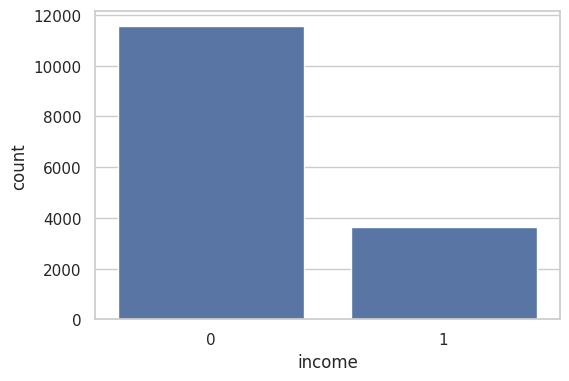

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)

df['income'].value_counts(normalize=True).round(2)

**INSIGHTS**
* The dataset shows a clear class imbalance, with approximately 76% of individuals earning <=50K and only 24% earning >50K.
* This indicates that high-income individuals form a minority group, making it important to identify the distinguishing characteristics of this segment.
* The imbalance suggests that factors such as education, occupation,and financial indicators may play a significant role in determining higher income.
* The subsequent analysis will focus on identifying patterns and relationships that explain why a smaller proportion of individuals fall into the >50K category.

## Section 4: Univariate Analysis

### Numerical Columns

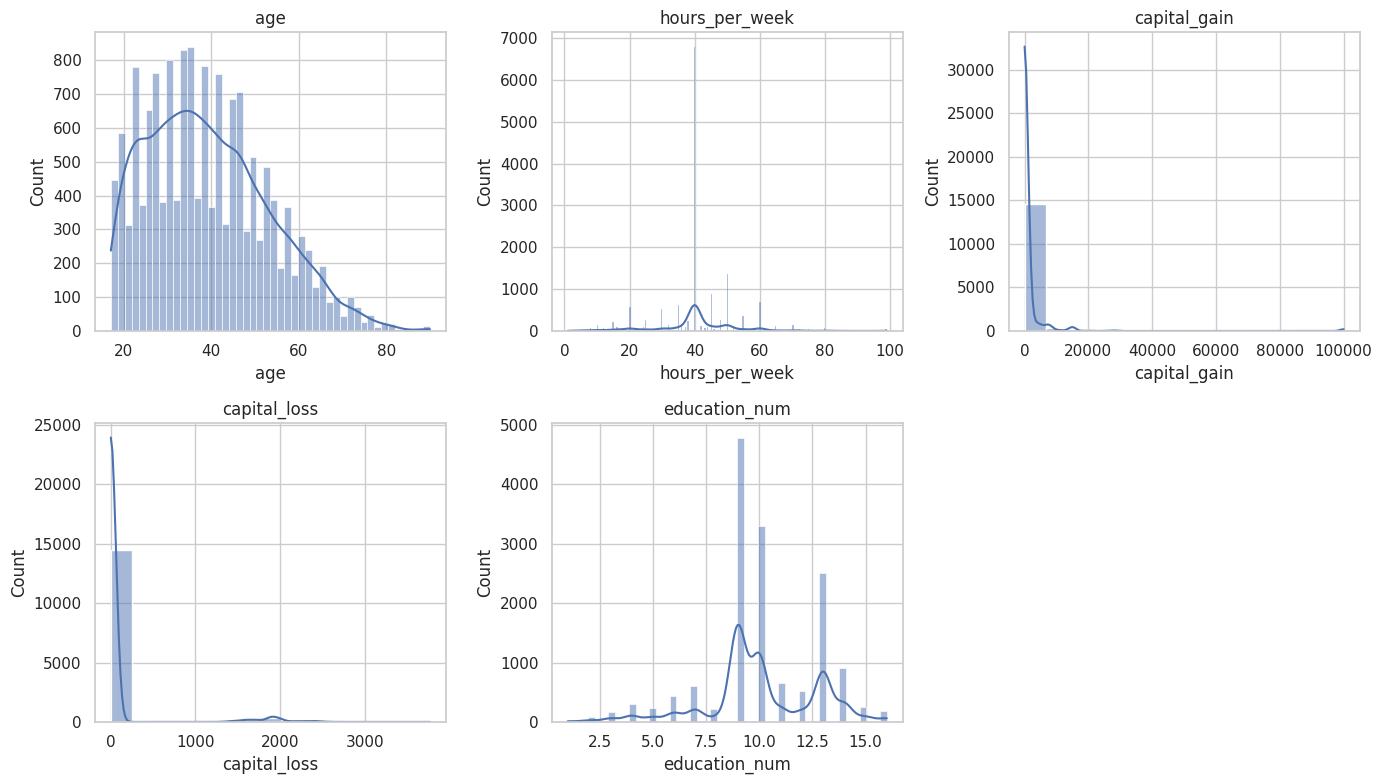

In [16]:
num_cols_for_uni = ['age', 'hours_per_week', 'capital_gain', 'capital_loss', 'education_num']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols_for_uni):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**INSIGHTS**

* Age distribution is concentrated between 25–45, representing the core working population.
Older age groups may have higher earning potential due to experience.

* Hours_per_week peaks around 40, indicating standard full-time employment. Variation exists, but higher hours alone may not guarantee higher income.

* Capital_gain is highly skewed, with most individuals having zero values and a small number showing very high gains. This suggests capital gain could strongly differentiate high-income individuals.

* Capital_loss is mostly zero, indicating limited financial loss across individuals. Its impact on income may be minimal compared to capital_gain.

* Education_num shows clustering around mid-level education, while higher values may be associated with higher income levels.

### Categorical Columns

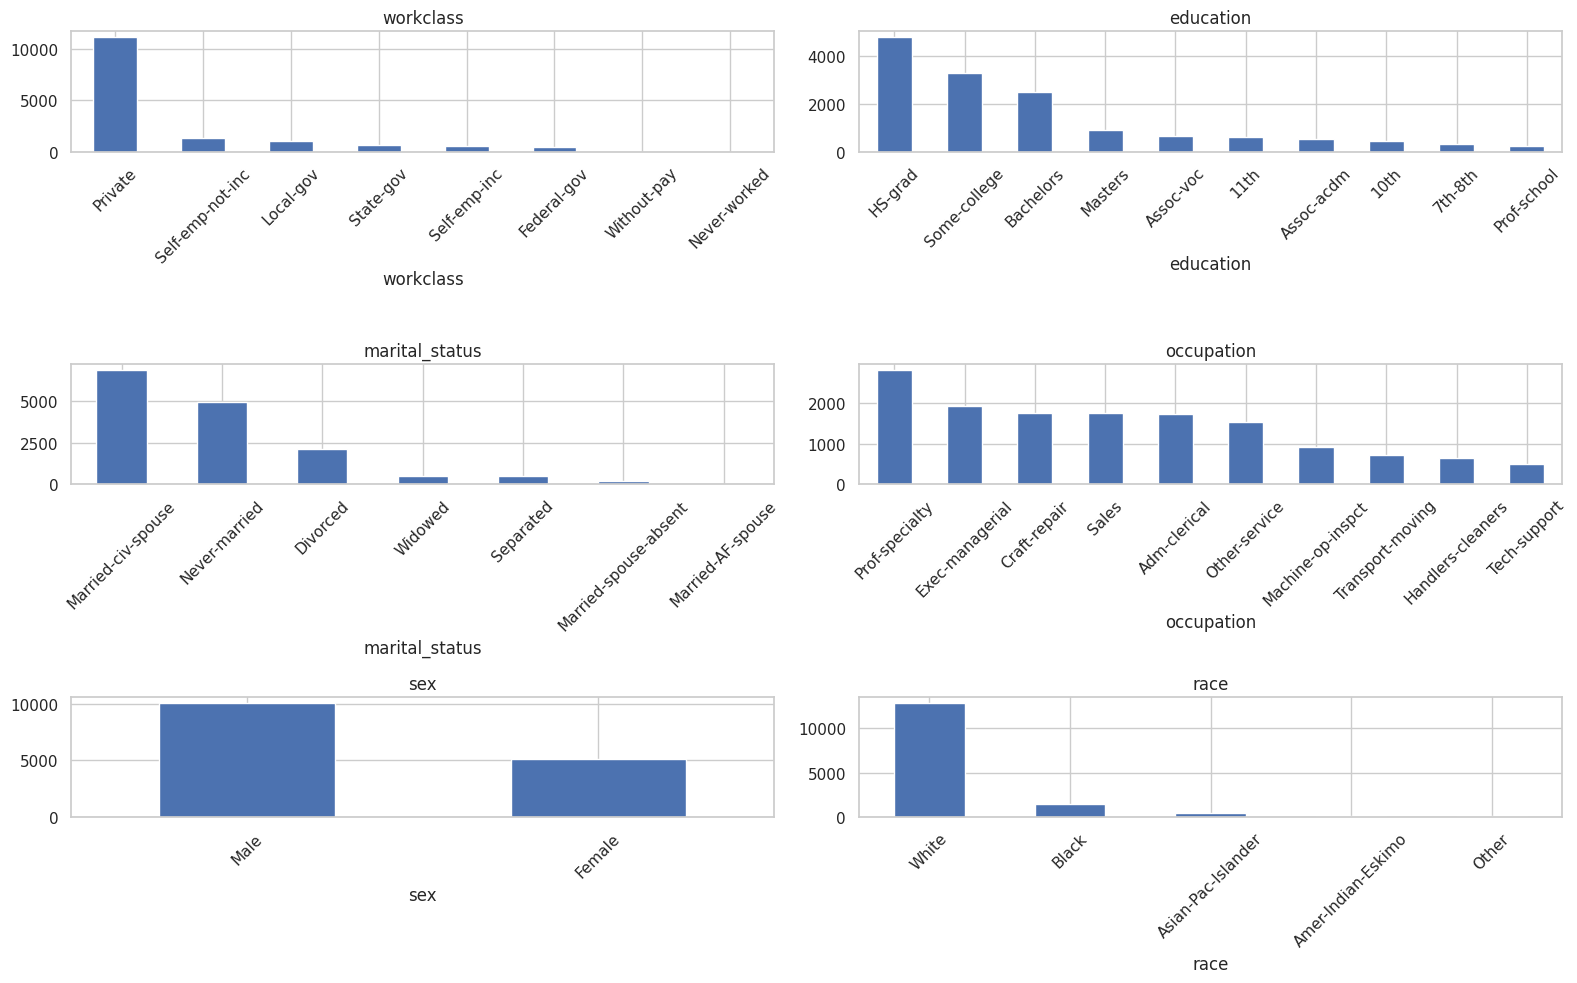

In [21]:
cat_cols_for_uni = ['workclass', 'education', 'marital_status', 'occupation', 'sex', 'race']

plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols_for_uni):
    plt.subplot(3, 2, i + 1)
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**INSIGHTS**
* The majority of individuals belong to the Private workclass, indicating that most of the workforce is employed in the private sector.

* Education levels are concentrated around HS-grad and Some-college, suggesting that a large portion of individuals have mid-level education.

* Married-civ-spouse and Never-married are the most common marital statuses, which may influence income patterns in later analysis.

* Occupation distribution shows diversity, with Prof-specialty and Exec-managerial being among the more prominent categories, which may relate to higher income roles.

* The dataset has a higher representation of males compared to females, which may impact observed income distribution.

* The dataset is heavily dominated by the White racial category, indicating potential imbalance that should be considered when interpreting income patterns.

## Section 5: Bivariate Analysis (Focus on income)

**INCOME vs EDUCATION**

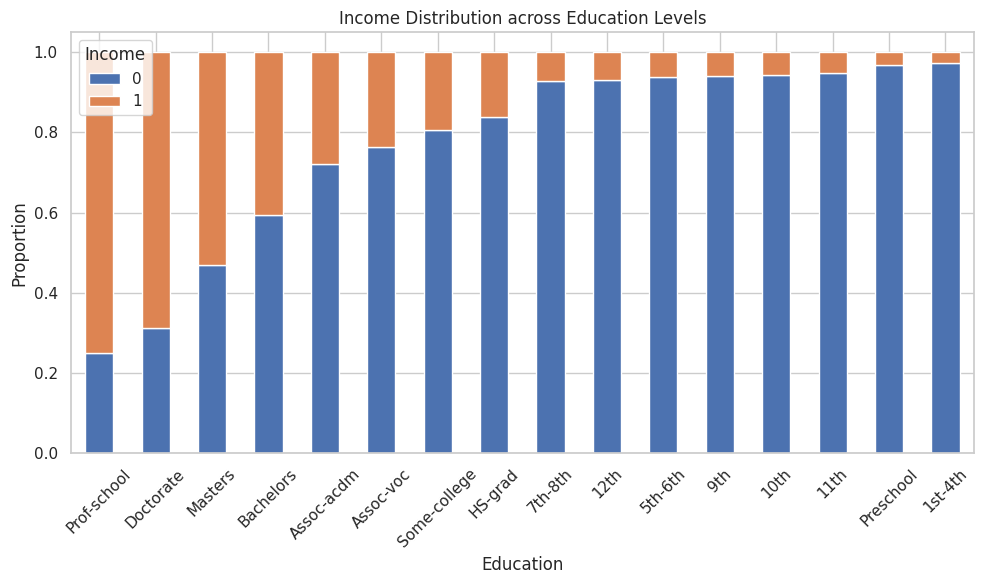

In [23]:
edu_income = pd.crosstab(df['education'], df['income'], normalize='index')

edu_income = edu_income.sort_values(by=1, ascending=False)
edu_income.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Income Distribution across Education Levels')
plt.xlabel('Education')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Income')

plt.tight_layout()
plt.show()

**INSIGHTS**

* Higher education levels (such as Bachelors, Masters, and Doctorate) show a significantly higher proportion of individuals earning >50K.

* Lower education levels (such as HS-grad, 11th, etc.) are dominated by individuals earning <=50K.

* This indicates a strong positive relationship between education level and earning potential.

* Education appears to be one of the most influential factors in determining whether an individual falls into the high-income category.

* This supports the hypothesis that higher educational attainment increases the likelihood of earning above 50K.

**INCOME vs OCCUPATION**

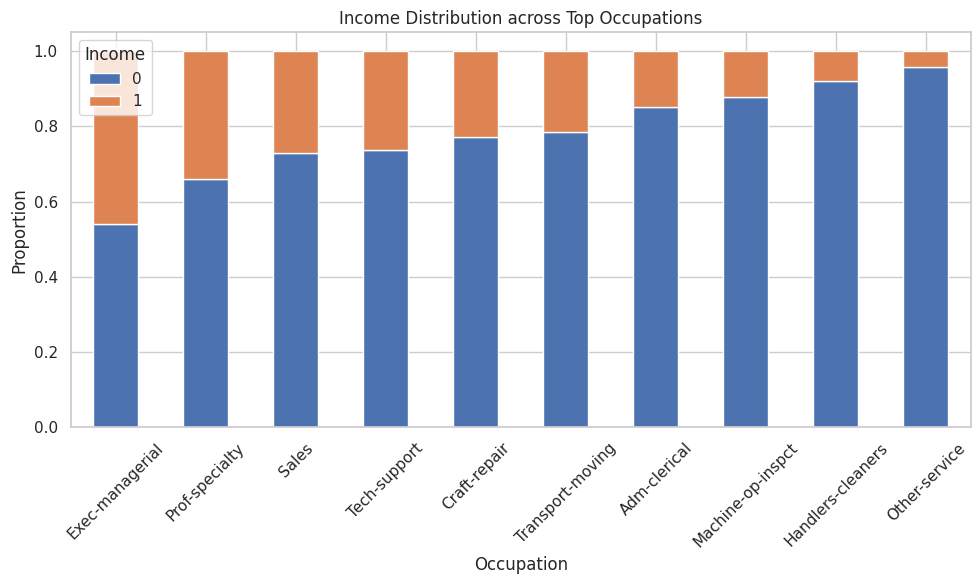

In [20]:
top_occupations = df['occupation'].value_counts().head(10).index

occ_income = pd.crosstab(
    df[df['occupation'].isin(top_occupations)]['occupation'],
    df[df['occupation'].isin(top_occupations)]['income'],
    normalize='index'
)
occ_income = occ_income.sort_values(by=1, ascending=False)

occ_income.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Income Distribution across Top Occupations')
plt.xlabel('Occupation')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Income')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Exec-managerial roles show the highest proportion of individuals earning >50K, indicating that leadership and decision-making positions are strongly associated with higher income.

* Prof-specialty occupations also have a high share of >50K earners, suggesting that specialized skills and professional expertise significantly increase earning potential.

* Occupations such as Adm-clerical, Machine-op-inspct, and Other-service are dominated by individuals earning <=50K, indicating lower-paying job roles.

* Technical roles like Tech-support and Sales show moderate proportions of high-income individuals, suggesting potential for growth but less consistency compared to managerial roles.

* Overall, occupation is a strong determinant of income, with high-income individuals concentrated in managerial and specialized professions.

**INCOME vs MARITAL STATUS**

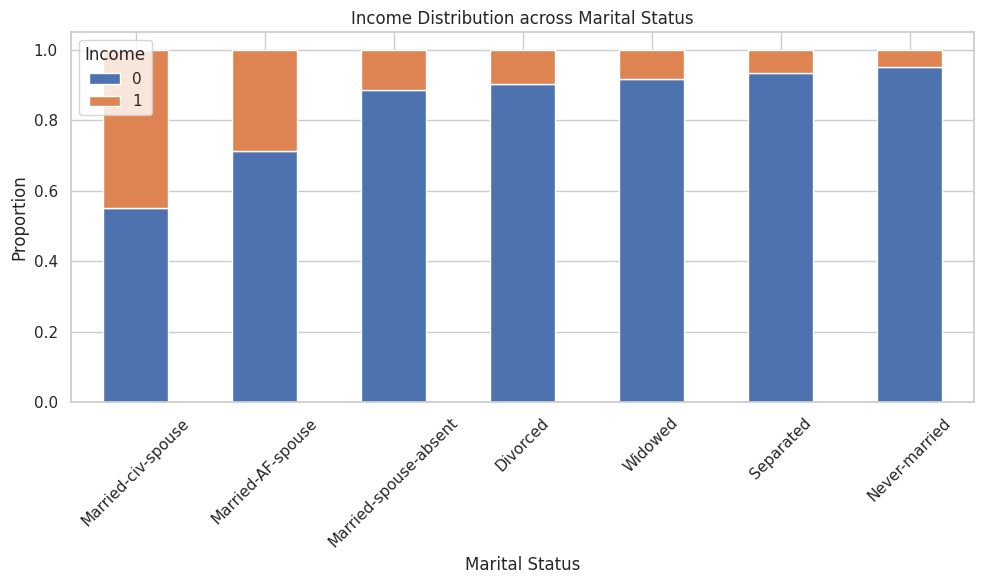

In [24]:
marital_income = pd.crosstab(df['marital_status'], df['income'], normalize='index')

marital_income = marital_income.sort_values(by=1, ascending=False)
marital_income.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Income Distribution across Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Income')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Married-civ-spouse individuals have the highest proportion of >50K earners, indicating a strong association between being married and higher income levels.

* Never-married individuals show a significantly lower proportion of >50K earners, suggesting that younger or less experienced individuals dominate this group.

* Categories like Divorced, Separated, and Widowed are largely dominated by <=50K earners, indicating relatively lower income levels in these groups.

* The variation in income distribution across marital status suggests that demographic factors such as age, stability, and household structure influence earning potential.

* Overall, marital status is an important socio-economic factor associated with income differences.

**INCOME vs SEX**

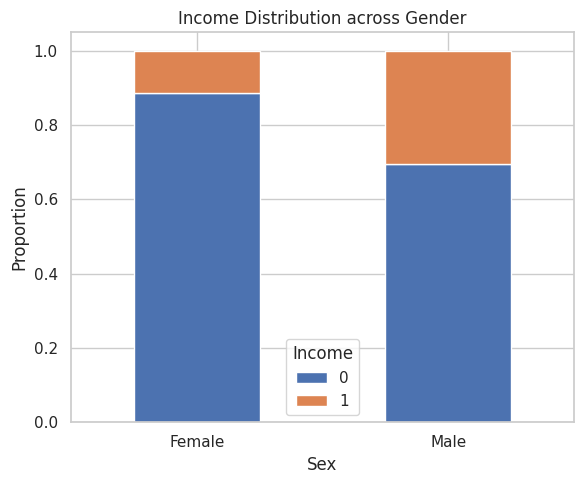

In [25]:
sex_income = pd.crosstab(df['sex'], df['income'], normalize='index')

sex_income.plot(kind='bar', stacked=True, figsize=(6,5))

plt.title('Income Distribution across Gender')
plt.xlabel('Sex')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Income')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Male individuals have a significantly higher proportion of >50K earners compared to female individuals.

* Female individuals are largely concentrated in the <=50K category, indicating a noticeable disparity in income distribution.
This suggests the presence of a gender gap in income within the dataset.

* The gap may be influenced by underlying factors such as occupation, work experience, working hours, and type of employment.

* Gender alone may not directly determine income, but it is strongly associated with differences in earning patterns.

**INCOME vs HOURS_PER_WEEK**

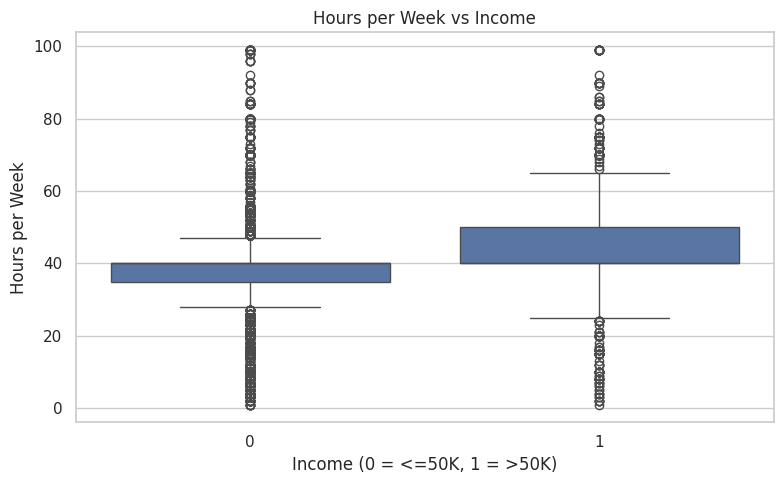

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='income', y='hours_per_week', data=df)

plt.title('Hours per Week vs Income')
plt.xlabel('Income (0 = <=50K, 1 = >50K)')
plt.ylabel('Hours per Week')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Individuals earning >50K tend to work slightly more hours on average compared to those earning <=50K, as seen from the higher median.

* However, there is a significant overlap in the distribution of working hours between both income groups.

* Many individuals in the <=50K group also work long hours, indicating that increased working hours alone does not guarantee higher income.

* The presence of numerous outliers in both groups suggests variability in working patterns across individuals.

* This indicates that factors such as education, occupation, and skill level play a more dominant role in determining income compared to hours worked.

* Overall, effort (measured in hours) has limited influence on income when compared to structural factors like job role and qualifications.

**WORKCLASS vs INCOME**

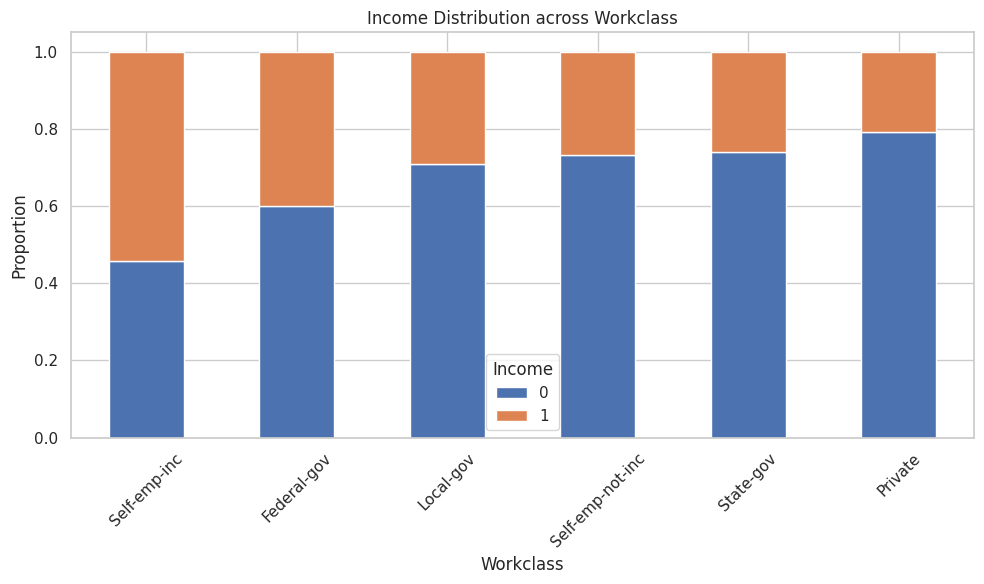

In [33]:
workclass_counts = df['workclass'].value_counts()
valid_classes = workclass_counts[workclass_counts > 100].index

filtered_df = df[df['workclass'].isin(valid_classes)]
workclass_income = pd.crosstab(filtered_df['workclass'], filtered_df['income'], normalize='index')
workclass_income = workclass_income.sort_values(by=1, ascending=False)
workclass_income.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Income Distribution across Workclass')
plt.xlabel('Workclass')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Income')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Self-emp-inc (self-employed with incorporated business) shows the highest proportion of individuals earning >50K, indicating strong earning potential in business ownership.

* Government sectors (federal and local) show moderate levels of high-income individuals, suggesting relatively stable but not top-tier earnings.

* Private sector and self-emp-not-inc categories have a higher concentration of ≤50K earners, indicating wider income variability and fewer high earners proportionally.

* Overall, workclass has a noticeable but limited impact on income, as differences between categories are not as strong as those observed in education or capital gain.

* This reinforces that **income is influenced by multiple interacting factors, rather than employment type alone**.


## Section 6: Multivariate Analysis

**EDUCATION + CAPITAL GAIN vs INCOME**

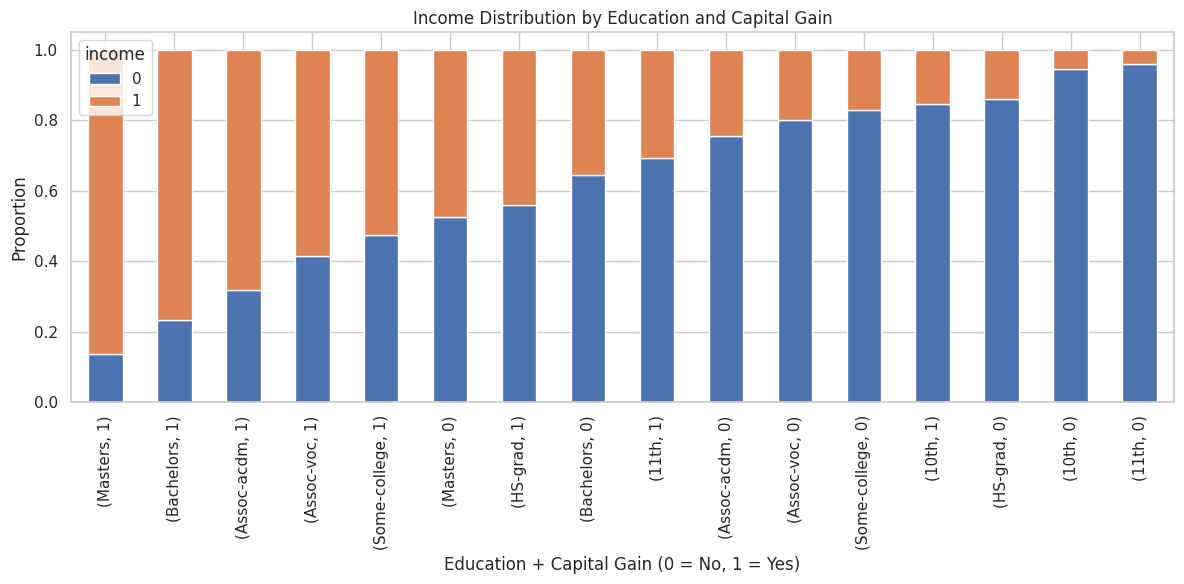

In [27]:
# capital flag
df['capital_flag'] = (df['capital_gain'] > 0).astype(int)

multi_edu_cap = pd.crosstab(
    [df['education'], df['capital_flag']],
    df['income'],
    normalize='index'
)

# top education levels for clarity
top_edu = df['education'].value_counts().head(8).index
multi_edu_cap = multi_edu_cap.loc[top_edu]

multi_edu_cap.sort_values(by=1, ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Income Distribution by Education and Capital Gain')
plt.xlabel('Education + Capital Gain (0 = No, 1 = Yes)')
plt.ylabel('Proportion')

plt.tight_layout()
plt.show()

**INSIGHTS**
* Individuals with both higher education and non-zero capital gain show the highest proportion of >50K earners.

* Within every education level, individuals with capital gain consistently have a much higher probability of earning >50K.

* This demonstrates that capital gain significantly amplifies the effect of education on income.

* Individuals with low education and no capital gain are overwhelmingly concentrated in the <=50K category.

* This confirms that income is influenced by the interaction of multiple factors, rather than any single variable alone.

* Combining human capital (education) and financial capital (capital gain) provides the strongest explanation for high income levels.

## Section 7: Outlier Detection

In [28]:
num_cols = ['age', 'hours_per_week', 'capital_gain', 'capital_loss']

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'age': 73, 'hours_per_week': 4322, 'capital_gain': 1320, 'capital_loss': 760}

**INSIGHTS**
* The number of outliers in **age** is very low (73), indicating age is relatively well distributed.

* A large number of outliers are present in **hours_per_week (4322)**, suggesting many individuals work unusually high or low hours compared to the average.

* **Capital_gain (1320)** and **capital_loss (760)** show significant outliers due to their highly skewed nature — most values are zero, with a few extremely high values.

* These extreme values represent real-world high-income individuals or investors rather than data errors.

* Therefore, outliers are **retained** as they provide important signals for predicting high income (>50K).


## Section 8: Feature Engineering

**CAPITAL FLAG**

In [29]:
df['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
df['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)

df[['capital_gain', 'has_capital_gain']].head()

,capital_gain,has_capital_gain
0,0,0
1,0,0
2,0,0
3,7688,1
4,0,0


**WORK HOURS CATEGORY**

In [30]:
def work_hours_category(hours):
    if hours < 30:
        return 'Part-time'
    elif hours <= 50:
        return 'Full-time'
    else:
        return 'Overtime'

df['work_type'] = df['hours_per_week'].apply(work_hours_category)

df['work_type'].value_counts()

,count
work_type,
Full-time,11499
Part-time,1955
Overtime,1763


**EDUCATION LEVEL GROUPING**

In [31]:
def education_group(edu):
    if edu in ['Bachelors', 'Masters', 'Doctorate', 'Prof-school']:
        return 'Higher Education'
    elif edu in ['HS-grad', 'Some-college', 'Assoc-acdm', 'Assoc-voc']:
        return 'Medium Education'
    else:
        return 'Low Education'

df['education_level'] = df['education'].apply(education_group)

df['education_level'].value_counts()

,count
education_level,
Medium Education,9271
Higher Education,3844
Low Education,2102


#Final Summary: Income Analysis using Census Dataset

This exploratory data analysis aimed to identify key factors influencing whether an individual earns more than $50K annually.

**Key Findings:**

• The dataset is imbalanced, with the majority of individuals earning ≤50K, which is important for modeling considerations.

• Education level shows a strong positive relationship with income — individuals with higher education (Bachelors, Masters, Doctorate) are significantly more likely to earn >50K.

• Occupation plays a crucial role, with roles like Exec-managerial and Prof-specialty having a higher proportion of high-income individuals.

• Marital status reveals that married individuals (especially married-civ-spouse) have a higher likelihood of earning >50K.

• Gender disparity is observed, where males have a higher proportion of high-income individuals compared to females.

• Working hours contribute to income differences — individuals earning >50K tend to work longer hours on average.

• Capital gain emerges as one of the strongest indicators of high income, with individuals having capital gains showing a significantly higher probability of earning >50K.

• Outlier analysis shows extreme values in capital gain, capital loss, and working hours, which represent real-world high earners and are therefore retained.

• Multivariate analysis confirms that income is influenced by a combination of factors, especially education and capital gain together.

**Conclusion:**

Income is not determined by a single variable but by the interaction of demographic, educational, and financial factors. Among all variables, education, occupation, and capital gain are the most influential predictors of high income.

This analysis provides a strong foundation for building predictive models and designing data-driven decision systems.